## 1. Import Libraries

Before analyzing the delivery dataset, we import the libraries required for data manipulation, numerical calculations, and feature engineering.


In [1]:
# Import libraries for data manipulation and numerical calculations
import pandas as pd
import numpy as np

## 2. Load Dataset

The raw food delivery dataset is loaded into a pandas DataFrame for further analysis and data cleaning.


In [2]:
# Load the raw delivery dataset into a pandas DataFrame
df = pd.read_csv("Food_Delivery_Times.csv")

# Display the first five rows to verify that the dataset was loaded correctly
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## 3. Initial Data Inspection

Before cleaning the dataset, we inspect its structure, data types, and basic information to understand the available variables and identify potential data quality issues.


In [3]:
# Display the number of rows and columns in the dataset
df.shape

(1000, 9)

## 4. Data Structure and Data Types

We inspect the dataset structure and data types to identify missing values and determine which columns require cleaning or transformation.


In [4]:
# Display information about columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


## 5. Missing Values

We identify the number of missing values in each column before applying any data cleaning strategy.


In [5]:
# Count missing values in each column
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

### 6. Checking Missing Values in the Weather Column

This step checks the frequency of each value in the `Weather` column. The `dropna=False` parameter ensures that missing values are also included in the output, allowing us to verify the number of missing values in this column.

In [6]:
# Count unique values in the Weather column, including missing values
df['Weather'].value_counts(dropna=False)

Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

### 7. Calculating the Percentage of Missing Values

We calculate the percentage of missing values in each column to assess the extent of missing data across the dataset.

In [7]:
# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Order_ID                  0.0
Distance_km               0.0
Weather                   3.0
Traffic_Level             3.0
Time_of_Day               3.0
Vehicle_Type              0.0
Preparation_Time_min      0.0
Courier_Experience_yrs    3.0
Delivery_Time_min         0.0
dtype: float64

### 8. Identifying Columns with Missing Values

We identify the columns that contain missing values to determine which parts of the dataset require further data cleaning.

In [8]:
# Identify columns that contain missing values
missing_percentage[missing_percentage > 0]

Weather                   3.0
Traffic_Level             3.0
Time_of_Day               3.0
Courier_Experience_yrs    3.0
dtype: float64

### 9. Counting Missing Values in Affected Columns

We count the exact number of missing values in the columns that contain missing data.

In [9]:
# Count missing values in columns with missing data
df[['Weather', 'Traffic_Level', 'Time_of_Day', 'Courier_Experience_yrs']].isnull().sum()

Weather                   30
Traffic_Level             30
Time_of_Day               30
Courier_Experience_yrs    30
dtype: int64

### 10. Checking Data Types of Affected Columns

We check the data types of the affected columns to determine the appropriate missing value treatment for each column.

In [10]:
# Check the data types of columns containing missing values
df[['Weather', 'Traffic_Level', 'Time_of_Day', 'Courier_Experience_yrs']].dtypes

Weather                    object
Traffic_Level              object
Time_of_Day                object
Courier_Experience_yrs    float64
dtype: object

### 11. Reviewing Categorical Values

We review the unique values in the categorical columns to understand their categories before handling missing values.

In [11]:
# Review the unique values in categorical columns
for column in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


Weather:
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

Traffic_Level:
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64

Time_of_Day:
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64


### 12. Reviewing Numeric Values

We review the distribution of the numeric column containing missing values to understand its range and identify any unusual values before handling missing data.

In [12]:
# Review the distribution of Courier_Experience_yrs
df['Courier_Experience_yrs'].describe()

count    970.000000
mean       4.579381
std        2.914394
min        0.000000
25%        2.000000
50%        5.000000
75%        7.000000
max        9.000000
Name: Courier_Experience_yrs, dtype: float64

### 13. Reviewing the Distribution of Courier Experience

We review the frequency of each value in the `Courier_Experience_yrs` column to understand its distribution before handling missing values.

In [13]:
# Count the frequency of each courier experience value
df['Courier_Experience_yrs'].value_counts(dropna=False).sort_index()

Courier_Experience_yrs
0.0     91
1.0    107
2.0     99
3.0     80
4.0     94
5.0     90
6.0    109
7.0     91
8.0    101
9.0    108
NaN     30
Name: count, dtype: int64

### 14. Comparing Mean and Median

We compare the mean and median of `Courier_Experience_yrs` to determine an appropriate central value for handling missing data.

In [14]:
# Compare the mean and median of courier experience
df['Courier_Experience_yrs'].mean(), df['Courier_Experience_yrs'].median()

(4.579381443298969, 5.0)

### 15. Handling Missing Values in Courier Experience

The `Courier_Experience_yrs` column contains 30 missing values. Since the median is 5 years and the variable represents a discrete numeric value, we use the median to fill the missing values.

In [15]:
# Fill missing courier experience values with the median
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(
    df['Courier_Experience_yrs'].median()
)

### 16. Verifying Missing Values After Imputation

We verify that all missing values in `Courier_Experience_yrs` have been successfully replaced.

In [16]:
# Check for remaining missing values in Courier_Experience_yrs
df['Courier_Experience_yrs'].isnull().sum()

0

### 17. Identifying the Most Frequent Categories

We identify the most frequent category in each categorical column to determine an appropriate strategy for handling missing values.

In [17]:
# Identify the most frequent category in each categorical column
for column in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    print(f"\n{column}:")
    print(df[column].mode()[0])


Weather:
Clear

Traffic_Level:
Medium

Time_of_Day:
Morning


### 18. Reviewing Categorical Distributions

We review the frequency and proportion of each category in the affected categorical columns to support the missing value treatment.

In [18]:
# Review the frequency and proportion of categories
for column in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))
    print(df[column].value_counts(normalize=True, dropna=False) * 100)


Weather:
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64
Weather
Clear    47.0
Rainy    20.4
Foggy    10.3
Snowy     9.7
Windy     9.6
NaN       3.0
Name: proportion, dtype: float64

Traffic_Level:
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64
Traffic_Level
Medium    39.0
Low       38.3
High      19.7
NaN        3.0
Name: proportion, dtype: float64

Time_of_Day:
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64
Time_of_Day
Morning      30.8
Evening      29.3
Afternoon    28.4
Night         8.5
NaN           3.0
Name: proportion, dtype: float64


### 19. Checking Missing Values Across Categorical Columns

We check whether missing values in the categorical columns occur in the same rows or across different rows.

In [19]:
# Check missing values across the affected categorical columns
df[['Weather', 'Traffic_Level', 'Time_of_Day']].isnull().sum(axis=1).value_counts().sort_index()

0    912
1     86
2      2
Name: count, dtype: int64

### 20. Inspecting Rows with Multiple Missing Values

We inspect the rows that contain missing values in more than one categorical column to understand their pattern before handling the missing data.

In [20]:
# Inspect rows with multiple missing values
df.loc[
    df[['Weather', 'Traffic_Level', 'Time_of_Day']].isnull().sum(axis=1) > 1,
    ['Weather', 'Traffic_Level', 'Time_of_Day']
]

,Weather,Traffic_Level,Time_of_Day
353,NaN,Low,NaN
379,Clear,NaN,NaN


### 21. Checking Remaining Missing Values

We check the remaining missing values after imputing `Courier_Experience_yrs` to identify the columns that still require treatment.

In [21]:
# Check remaining missing values after imputing courier experience
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs     0
Delivery_Time_min          0
dtype: int64

### 22. Reviewing the Mode for Categorical Columns

We review the most frequent category in each categorical column to determine the value used for missing value imputation.

In [22]:
# Identify the most frequent category in each categorical column
for column in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    print(f"{column}: {df[column].mode()[0]}")

Weather: Clear
Traffic_Level: Medium
Time_of_Day: Morning


### 23. Handling Missing Values in Categorical Columns

We fill the missing values in the categorical columns using the most frequent category (mode) of each column.

In [23]:
# Fill missing categorical values with the mode of each column
for column in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[column] = df[column].fillna(df[column].mode()[0])

### 24. Verifying Missing Values After Imputation

We verify that all missing values have been successfully handled after applying the imputation strategies.

In [24]:
# Check for remaining missing values
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

### 25. Checking for Duplicate Rows

We check for duplicate rows to ensure that the dataset does not contain repeated records that could affect the analysis.

In [25]:
# Count duplicate rows
df.duplicated().sum()

0

In [26]:
# Review the summary statistics of numeric columns
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.592000,56.732000
std,288.819436,5.696656,7.204553,2.871198,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### 26. Reviewing Numeric Column Ranges

We review the ranges of the main numeric variables to identify values that may require further investigation.

In [27]:
# Review the ranges of the main numeric variables
df[['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']].describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.592000,56.732000
std,5.696656,7.204553,2.871198,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


### 27. Detecting Potential Outliers Using the IQR Method

We use the Interquartile Range (IQR) method to identify potential outliers in the main numeric variables.

The IQR is calculated as the difference between the third quartile (Q3) and the first quartile (Q1). Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are flagged as potential outliers.

In [28]:
# Identify potential outliers using the IQR method
numeric_columns = [
    'Distance_km',
    'Preparation_Time_min',
    'Courier_Experience_yrs',
    'Delivery_Time_min'
]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"\n{column}:")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Potential Outliers: {len(outliers)}")


Distance_km:
Lower Bound: -9.76
Upper Bound: 29.89
Potential Outliers: 0

Preparation_Time_min:
Lower Bound: -7.00
Upper Bound: 41.00
Potential Outliers: 0

Courier_Experience_yrs:
Lower Bound: -5.50
Upper Bound: 14.50
Potential Outliers: 0

Delivery_Time_min:
Lower Bound: -4.00
Upper Bound: 116.00
Potential Outliers: 6


### 28. Inspecting Potential Outliers in Delivery Time

We inspect the records flagged as potential outliers in `Delivery_Time_min` to determine whether they represent unusual but valid delivery times or potential data quality issues.

In [29]:
# Inspect potential outliers in Delivery_Time_min
df[df['Delivery_Time_min'] > 116]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141
379,814,18.46,Clear,Medium,Morning,Scooter,29,1.0,153
452,394,15.64,Rainy,Low,Morning,Bike,20,4.0,141
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126
924,428,17.81,Windy,High,Evening,Bike,21,4.0,122


### 29. Checking Value Ranges for Data Quality

We check the minimum and maximum values of the main numeric variables to identify any values that fall outside reasonable ranges.

In [30]:
# Check the minimum and maximum values of the main numeric variables
df[['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']].agg(['min', 'max'])

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
min,0.59,5,0.0,8
max,19.99,29,9.0,153


### 30. Checking Consistency Between Preparation and Delivery Time

We check whether `Delivery_Time_min` is always greater than or equal to `Preparation_Time_min`, since delivery time represents the overall delivery duration and should include the preparation stage.

In [31]:
# Check for records where delivery time is less than preparation time
df[df['Delivery_Time_min'] < df['Preparation_Time_min']]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


### 31. Checking Categorical Value Consistency

We check the unique values in the categorical columns to ensure that the dataset contains only expected categories and no inconsistent or unexpected values.

In [32]:
# Check unique values in categorical columns
for column in ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']:
    print(f"\n{column}:")
    print(df[column].unique())


Weather:
['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy']

Traffic_Level:
['Low' 'Medium' 'High']

Time_of_Day:
['Afternoon' 'Evening' 'Night' 'Morning']

Vehicle_Type:
['Scooter' 'Bike' 'Car']


### 32. Checking Order ID Uniqueness

We check whether each `Order_ID` is unique to ensure that every delivery record represents a distinct order.

In [33]:
# Check for duplicate Order_ID values
df['Order_ID'].duplicated().sum()

0

### 33. Checking Negative and Zero Values

We check whether the main numeric variables contain negative or zero values that may indicate potential data quality issues.

In [34]:
# Check for negative and zero values in the main numeric variables
numeric_columns = [
    'Distance_km',
    'Preparation_Time_min',
    'Courier_Experience_yrs',
    'Delivery_Time_min'
]

for column in numeric_columns:
    print(f"\n{column}:")
    print("Negative values:", (df[column] < 0).sum())
    print("Zero values:", (df[column] == 0).sum())


Distance_km:
Negative values: 0
Zero values: 0

Preparation_Time_min:
Negative values: 0
Zero values: 0

Courier_Experience_yrs:
Negative values: 0
Zero values: 91

Delivery_Time_min:
Negative values: 0
Zero values: 0


### 34. Checking the Distribution of Vehicle Types

We review the frequency of each vehicle type to understand the distribution of delivery vehicles in the dataset.

In [35]:
# Count the frequency of each vehicle type
df['Vehicle_Type'].value_counts()

Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64

### 35. Checking the Distribution of Traffic Levels

We review the frequency of each traffic level to understand the distribution of traffic conditions in the dataset.

In [36]:
# Count the frequency of each traffic level
df['Traffic_Level'].value_counts()

Traffic_Level
Medium    420
Low       383
High      197
Name: count, dtype: int64

### 36. Checking the Distribution of Weather Conditions

We review the frequency of each weather condition to understand the distribution of weather conditions in the dataset.

In [37]:
# Count the frequency of each weather condition
df['Weather'].value_counts()

Weather
Clear    500
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

### 37. Checking the Distribution of Time of Day

We review the frequency of each time-of-day category to understand the distribution of orders across different periods of the day.

In [38]:
# Count the frequency of each time-of-day category
df['Time_of_Day'].value_counts()

Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

### 38. Checking the Distribution of Courier Experience

We review the frequency of each courier experience level to understand the distribution of courier experience in the dataset.

In [39]:
# Count the frequency of each courier experience level
df['Courier_Experience_yrs'].value_counts().sort_index()

Courier_Experience_yrs
0.0     91
1.0    107
2.0     99
3.0     80
4.0     94
5.0    120
6.0    109
7.0     91
8.0    101
9.0    108
Name: count, dtype: int64

### 39. Checking the Distribution of Delivery Time

We review the frequency of delivery times to understand how delivery duration is distributed across the dataset.

In [40]:
# Review the frequency of delivery times
df['Delivery_Time_min'].value_counts().sort_index()

Delivery_Time_min
8      1
13     1
14     4
15     1
16     4
      ..
122    1
123    1
126    1
141    2
153    1
Name: count, Length: 108, dtype: int64

### 40. Reviewing Delivery Time Distribution with Summary Statistics

We review the summary statistics of `Delivery_Time_min` to understand its central tendency, variability, and range.

In [41]:
# Review summary statistics for delivery time
df['Delivery_Time_min'].describe()

count    1000.000000
mean       56.732000
std        22.070915
min         8.000000
25%        41.000000
50%        55.500000
75%        71.000000
max       153.000000
Name: Delivery_Time_min, dtype: float64

### 41. Visualizing Delivery Time Distribution

We visualize the distribution of `Delivery_Time_min` to better understand its spread, concentration, and potential extreme values.

In [42]:
# Import matplotlib for data visualization
import matplotlib.pyplot as plt

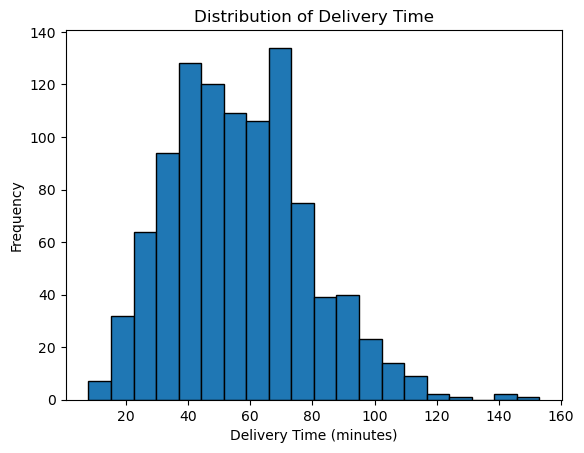

In [43]:
# Plot the distribution of delivery time
df['Delivery_Time_min'].plot(kind='hist', bins=20, edgecolor='black')

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

### 42. Checking Average Delivery Time by Traffic Level

We compare the average delivery time across different traffic levels to investigate whether traffic conditions are associated with differences in delivery duration.

In [44]:
# Calculate average delivery time by traffic level
df.groupby('Traffic_Level')['Delivery_Time_min'].mean()

Traffic_Level
High      64.807107
Low       52.885117
Medium    56.452381
Name: Delivery_Time_min, dtype: float64

### 43. Visualizing Average Delivery Time by Traffic Level

We visualize the average delivery time for each traffic level using a bar chart to make the comparison easier to interpret.

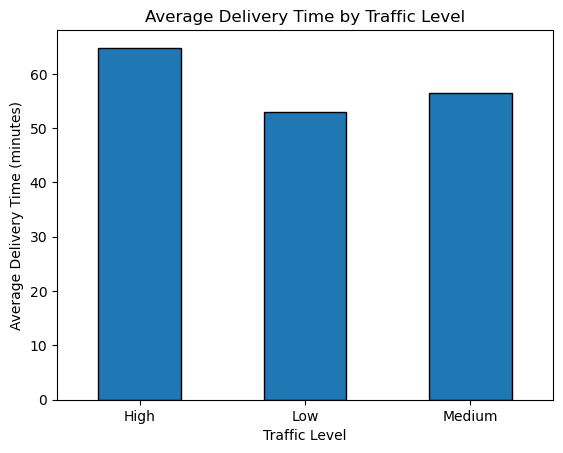

In [45]:
# Plot average delivery time by traffic level
df.groupby('Traffic_Level')['Delivery_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Delivery Time by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 44. Checking Average Delivery Time by Weather

We compare the average delivery time across different weather conditions to investigate whether weather conditions are associated with differences in delivery duration.

In [46]:
# Calculate average delivery time by weather condition
df.groupby('Weather')['Delivery_Time_min'].mean()

Weather
Clear    53.150000
Foggy    59.466019
Rainy    59.794118
Snowy    67.113402
Windy    55.458333
Name: Delivery_Time_min, dtype: float64

### 45. Visualizing Average Delivery Time by Weather

We visualize the average delivery time for each weather condition using a bar chart to make the comparison easier to interpret.

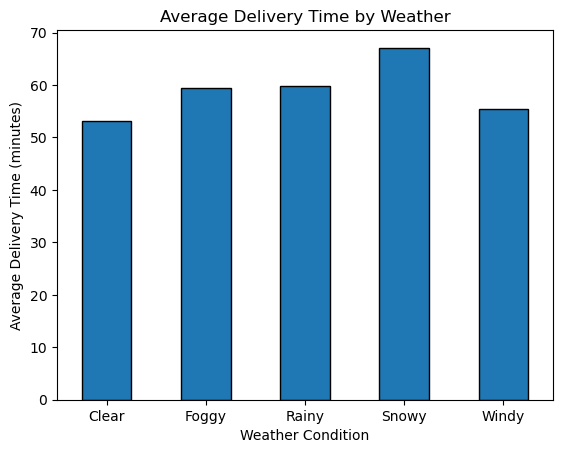

In [47]:
# Plot average delivery time by weather condition
df.groupby('Weather')['Delivery_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Delivery Time by Weather')
plt.xlabel('Weather Condition')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 46. Checking Average Delivery Time by Vehicle Type

We compare the average delivery time across different vehicle types to investigate whether vehicle type is associated with differences in delivery duration.

In [48]:
# Calculate average delivery time by vehicle type
df.groupby('Vehicle_Type')['Delivery_Time_min'].mean()

Vehicle_Type
Bike       56.574553
Car        58.200000
Scooter    56.046358
Name: Delivery_Time_min, dtype: float64

### 47. Visualizing Average Delivery Time by Vehicle Type

We visualize the average delivery time for each vehicle type using a bar chart to make the comparison easier to interpret.

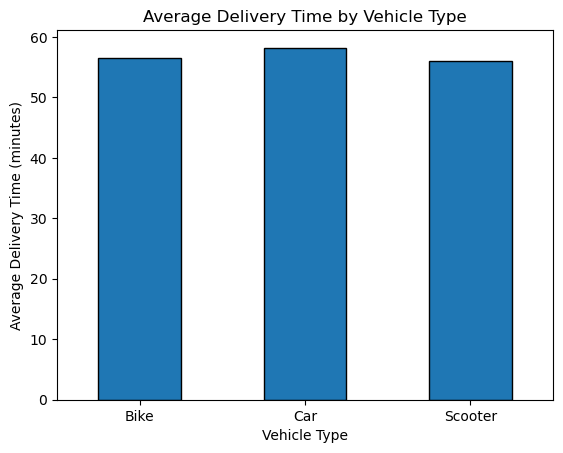

In [49]:
# Plot average delivery time by vehicle type
df.groupby('Vehicle_Type')['Delivery_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Delivery Time by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 48. Checking Average Delivery Time by Time of Day

We compare the average delivery time across different times of day to investigate whether the time of day is associated with differences in delivery duration.

In [50]:
# Calculate average delivery time by time of day
df.groupby('Time_of_Day')['Delivery_Time_min'].mean()

Time_of_Day
Afternoon    56.080986
Evening      57.481229
Morning      57.011834
Night        55.211765
Name: Delivery_Time_min, dtype: float64

### 49. Visualizing Average Delivery Time by Time of Day

We visualize the average delivery time across different times of day using a bar chart to make the comparison easier to interpret.

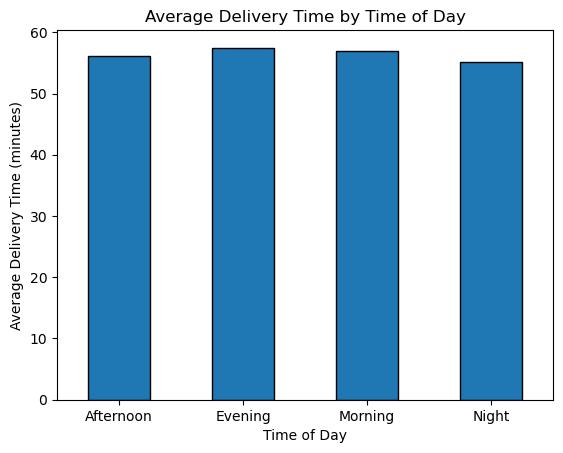

In [51]:
# Plot average delivery time by time of day
df.groupby('Time_of_Day')['Delivery_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Delivery Time by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.show()

# Calculate average delivery time by courier experience
df.groupby('Courier_Experience_yrs')['Delivery_Time_min'].mean()

In [52]:
# Calculate average delivery time by courier experience
df.groupby('Courier_Experience_yrs')['Delivery_Time_min'].mean()

Courier_Experience_yrs
0.0    60.230769
1.0    60.485981
2.0    54.373737
3.0    60.275000
4.0    59.595745
5.0    54.300000
6.0    56.541284
7.0    54.846154
8.0    53.990099
9.0    54.157407
Name: Delivery_Time_min, dtype: float64

### 51. Visualizing Average Delivery Time by Courier Experience

We visualize the average delivery time across different courier experience levels using a bar chart to make the comparison easier to interpret.

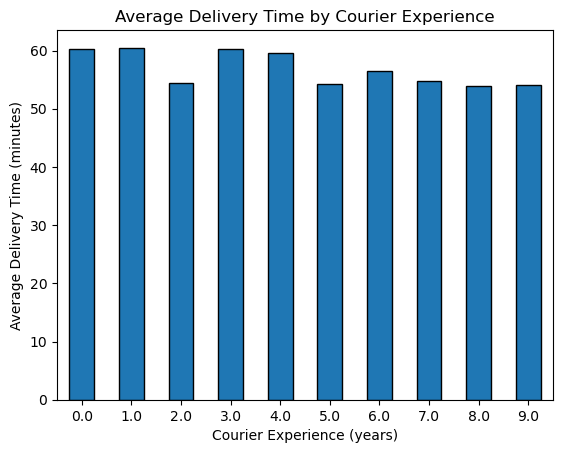

In [53]:
# Plot average delivery time by courier experience
df.groupby('Courier_Experience_yrs')['Delivery_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Delivery Time by Courier Experience')
plt.xlabel('Courier Experience (years)')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 52. Checking Average Delivery Time by Preparation Time

We compare the average delivery time across different preparation times to investigate whether longer preparation times are generally associated with longer delivery durations.

The results show some variation across individual preparation times, but higher preparation times are generally associated with higher average delivery times.

In [54]:
# Calculate average delivery time by preparation time
df.groupby('Preparation_Time_min')['Delivery_Time_min'].mean()

Preparation_Time_min
5     47.833333
6     42.659091
7     48.648649
8     54.523810
9     43.195652
10    47.872340
11    53.586957
12    62.315789
13    48.000000
14    50.711538
15    54.689655
16    54.857143
17    55.800000
18    56.607143
19    57.714286
20    64.205128
21    59.410256
22    62.904762
23    59.000000
24    63.027027
25    66.979167
26    61.450000
27    69.050000
28    65.475000
29    69.282051
Name: Delivery_Time_min, dtype: float64

### 53. Visualizing Average Delivery Time by Preparation Time

We visualize the average delivery time across different preparation times using a line chart to better understand the overall relationship and variation between the two variables.

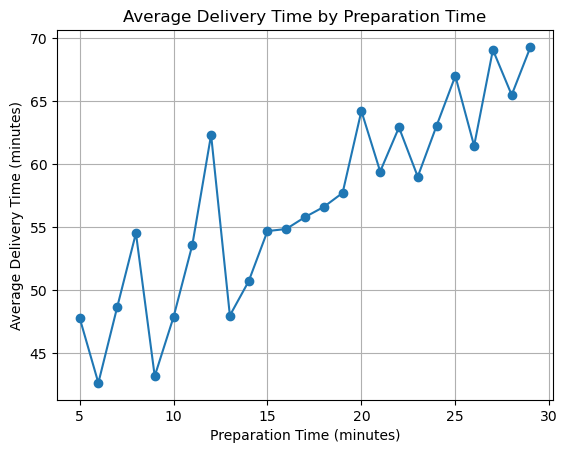

In [55]:
# Plot average delivery time by preparation time
df.groupby('Preparation_Time_min')['Delivery_Time_min'].mean().plot(
    kind='line',
    marker='o'
)

plt.title('Average Delivery Time by Preparation Time')
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Average Delivery Time (minutes)')
plt.grid(True)
plt.show()

### 54. Checking the Relationship Between Distance and Delivery Time

We compare delivery distance with delivery time to investigate whether longer delivery distances are associated with longer delivery durations.

In [56]:
# Calculate average delivery time by distance
df.groupby('Distance_km')['Delivery_Time_min'].mean()

Distance_km
0.59      27.0
0.60      30.0
0.61      16.0
0.64      24.0
0.68      50.0
         ...  
19.81     89.0
19.86     71.0
19.93     59.0
19.94     83.0
19.99    112.0
Name: Delivery_Time_min, Length: 785, dtype: float64

### 55. Grouping Distance into Ranges

Since `Distance_km` contains many unique values, we group the distances into ranges to make the comparison of delivery times more meaningful and easier to interpret.

In [57]:
# Group distance values into four ranges
df['Distance_Range'] = pd.cut(
    df['Distance_km'],
    bins=[0, 5, 10, 15, 20],
    labels=['0-5 km', '5-10 km', '10-15 km', '15-20 km']
)

### 56. Checking Average Delivery Time by Distance Range

We compare the average delivery time across different distance ranges to investigate whether longer delivery distances are associated with longer delivery durations.

In [58]:
# Calculate average delivery time by distance range
df.groupby('Distance_Range', observed=True)['Delivery_Time_min'].mean()

Distance_Range
0-5 km      34.326613
5-10 km     49.029046
10-15 km    63.361538
15-20 km    79.398406
Name: Delivery_Time_min, dtype: float64

### 57. Visualizing Average Delivery Time by Distance Range

We visualize the average delivery time across distance ranges using a bar chart to make the relationship between delivery distance and delivery duration easier to interpret.

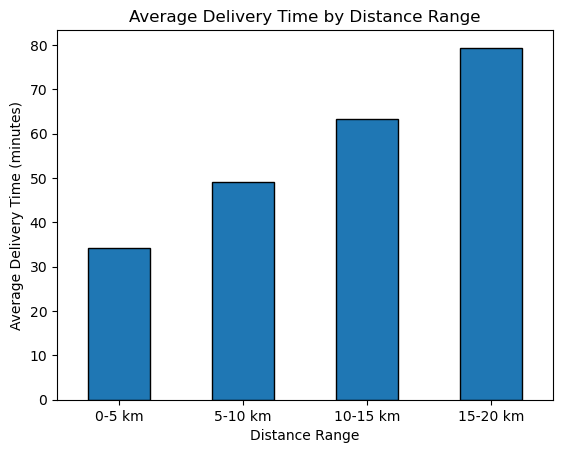

In [59]:
# Plot average delivery time by distance range
df.groupby('Distance_Range', observed=True)['Delivery_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Delivery Time by Distance Range')
plt.xlabel('Distance Range')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 58. Comparing Preparation Time and Delivery Time

We compare preparation time with delivery time to examine how the preparation stage contributes to the overall delivery duration.

In [60]:
# Calculate the average preparation time and delivery time
df[['Preparation_Time_min', 'Delivery_Time_min']].mean()

Preparation_Time_min    16.982
Delivery_Time_min       56.732
dtype: float64

### 59. Calculating the Post-Preparation Delivery Time

Since `Delivery_Time_min` represents the overall delivery duration and includes the preparation stage, we calculate the time remaining after preparation to examine the post-preparation portion of the delivery process.

In [61]:
# Calculate the time remaining after preparation
df['Post_Preparation_Time_min'] = (
    df['Delivery_Time_min'] - df['Preparation_Time_min']
)

df['Post_Preparation_Time_min'].describe()

count    1000.000000
mean       39.750000
std        21.006827
min         2.000000
25%        22.750000
50%        38.500000
75%        53.000000
max       124.000000
Name: Post_Preparation_Time_min, dtype: float64

### 60. Comparing Average Post-Preparation Time Across Traffic Levels

We compare the average post-preparation delivery time across different traffic levels to investigate whether traffic conditions are associated with differences in the time spent after preparation.

In [62]:
# Calculate average post-preparation time by traffic level
df.groupby('Traffic_Level')['Post_Preparation_Time_min'].mean()

Traffic_Level
High      48.071066
Low       35.657963
Medium    39.578571
Name: Post_Preparation_Time_min, dtype: float64

### 61. Visualizing Average Post-Preparation Time by Traffic Level

We visualize the average post-preparation delivery time across different traffic levels to make the relationship easier to interpret.

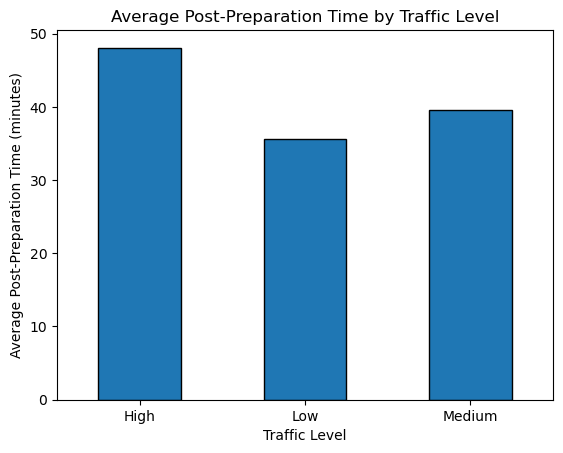

In [63]:
# Plot average post-preparation time by traffic level
df.groupby('Traffic_Level')['Post_Preparation_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 62. Comparing Average Post-Preparation Time Across Weather Conditions

We compare the average post-preparation delivery time across different weather conditions to investigate whether weather conditions are associated with differences in the time spent after preparation.

In [64]:
# Calculate average post-preparation time by weather condition
df.groupby('Weather')['Post_Preparation_Time_min'].mean()

Weather
Clear    36.074000
Foggy    42.834951
Rainy    42.573529
Snowy    49.711340
Windy    39.520833
Name: Post_Preparation_Time_min, dtype: float64

### 63. Visualizing Average Post-Preparation Time by Weather

We visualize the average post-preparation delivery time across different weather conditions to make the observed differences easier to interpret.

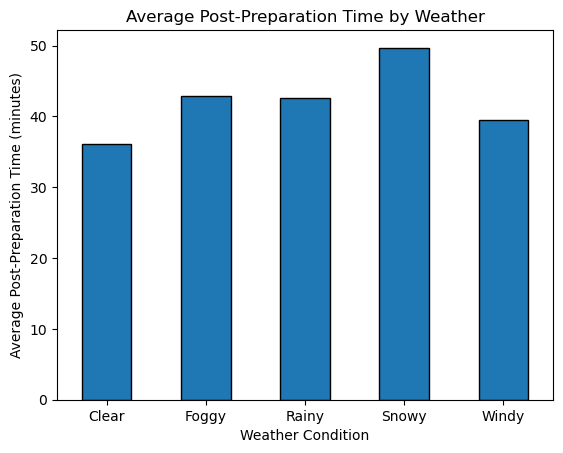

In [65]:
# Plot average post-preparation time by weather condition
df.groupby('Weather')['Post_Preparation_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Weather')
plt.xlabel('Weather Condition')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 64. Comparing Average Post-Preparation Time Across Vehicle Types

We compare the average post-preparation delivery time across different vehicle types to investigate whether vehicle type is associated with differences in the time spent after preparation.

In [66]:
# Calculate average post-preparation time by vehicle type
df.groupby('Vehicle_Type')['Post_Preparation_Time_min'].mean()

Vehicle_Type
Bike       39.723658
Car        41.210256
Scooter    38.850993
Name: Post_Preparation_Time_min, dtype: float64

### 65. Visualizing Average Post-Preparation Time by Vehicle Type

We visualize the average post-preparation delivery time across different vehicle types to make the observed differences easier to interpret.

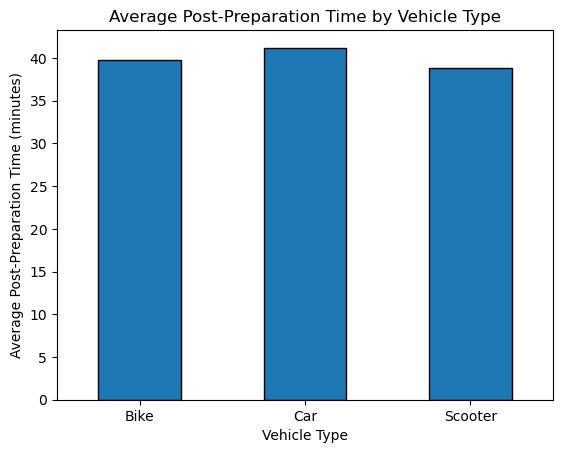

In [67]:
# Plot average post-preparation time by vehicle type
df.groupby('Vehicle_Type')['Post_Preparation_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 66. Comparing Average Post-Preparation Time Across Times of Day

We compare the average post-preparation delivery time across different times of day to investigate whether the time of day is associated with differences in the time spent after preparation.

In [68]:
# Calculate average post-preparation time by time of day
df.groupby('Time_of_Day')['Post_Preparation_Time_min'].mean()

Time_of_Day
Afternoon    39.281690
Evening      40.068259
Morning      40.292899
Night        38.058824
Name: Post_Preparation_Time_min, dtype: float64

### 67. Visualizing Average Post-Preparation Time by Time of Day

We visualize the average post-preparation delivery time across different times of day to make the observed differences easier to interpret.

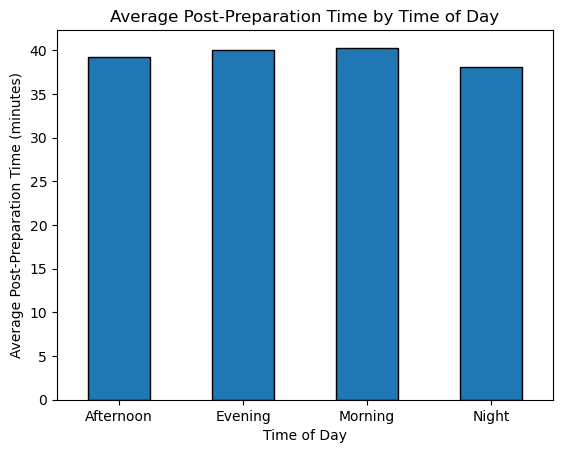

In [69]:
# Plot average post-preparation time by time of day
df.groupby('Time_of_Day')['Post_Preparation_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

# Calculate average post-preparation time by courier experience
df.groupby('Courier_Experience_yrs')['Post_Preparation_Time_min'].mean()

In [70]:
# Calculate average post-preparation time by courier experience
df.groupby('Courier_Experience_yrs')['Post_Preparation_Time_min'].mean()

Courier_Experience_yrs
0.0    42.516484
1.0    43.392523
2.0    38.000000
3.0    42.287500
4.0    41.478723
5.0    38.033333
6.0    40.165138
7.0    37.725275
8.0    38.356436
9.0    36.527778
Name: Post_Preparation_Time_min, dtype: float64

### 69. Visualizing Average Post-Preparation Time by Courier Experience

We visualize the average post-preparation delivery time across different courier experience levels to better understand the observed variation across experience levels.

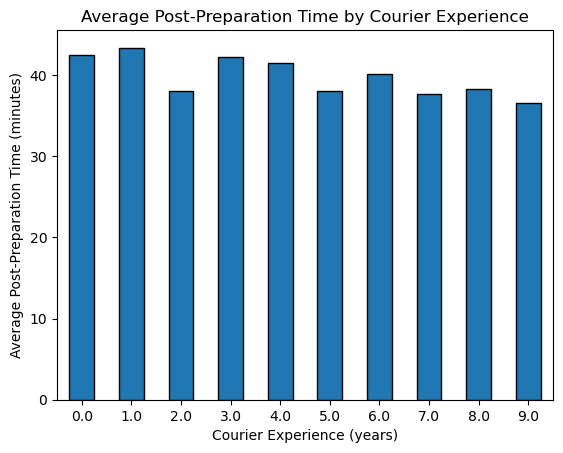

In [71]:
# Plot average post-preparation time by courier experience
df.groupby('Courier_Experience_yrs')['Post_Preparation_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Courier Experience')
plt.xlabel('Courier Experience (years)')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 70. Comparing Average Post-Preparation Time by Distance Range

We compare the average post-preparation delivery time across different distance ranges to investigate whether longer delivery distances are associated with longer post-preparation delivery times.

In [72]:
# Calculate average post-preparation time by distance range
df.groupby('Distance_Range', observed=True)['Post_Preparation_Time_min'].mean()

Distance_Range
0-5 km      17.467742
5-10 km     31.506224
10-15 km    47.069231
15-20 km    62.099602
Name: Post_Preparation_Time_min, dtype: float64

### 71. Visualizing Average Post-Preparation Time by Distance Range

We visualize the average post-preparation delivery time across distance ranges to make the observed relationship between delivery distance and post-preparation time easier to interpret.

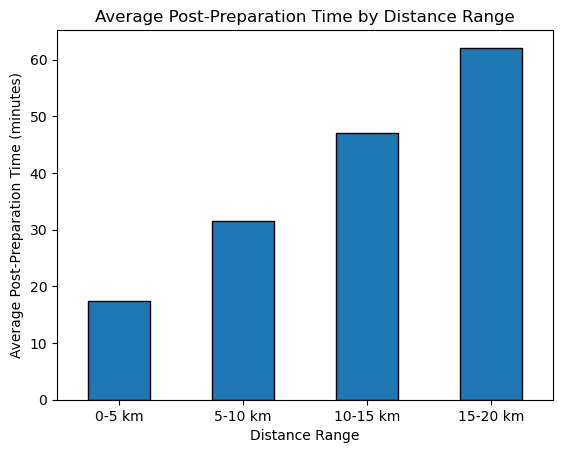

In [73]:
# Plot average post-preparation time by distance range
df.groupby('Distance_Range', observed=True)['Post_Preparation_Time_min'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Distance Range')
plt.xlabel('Distance Range')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 72. Comparing Delivery Time and Post-Preparation Time

We compare the overall delivery time with the post-preparation portion to understand how much of the delivery duration occurs after the preparation stage.

In [74]:
# Calculate the average overall delivery time and post-preparation time
df[['Delivery_Time_min', 'Post_Preparation_Time_min']].mean()

Delivery_Time_min            56.732
Post_Preparation_Time_min    39.750
dtype: float64

### 73. Calculating the Average Share of Post-Preparation Time

We calculate the average share of post-preparation time relative to the overall delivery time to understand how much of the delivery duration occurs after preparation.

In [75]:
# Calculate the average share of post-preparation time
post_preparation_share = (
    df['Post_Preparation_Time_min'] / df['Delivery_Time_min']
).mean()

post_preparation_share

0.6672872213403177

### 74. Visualizing the Average Time Components

We compare the average preparation time with the average post-preparation time to visualize how the overall delivery duration is distributed across these two components.

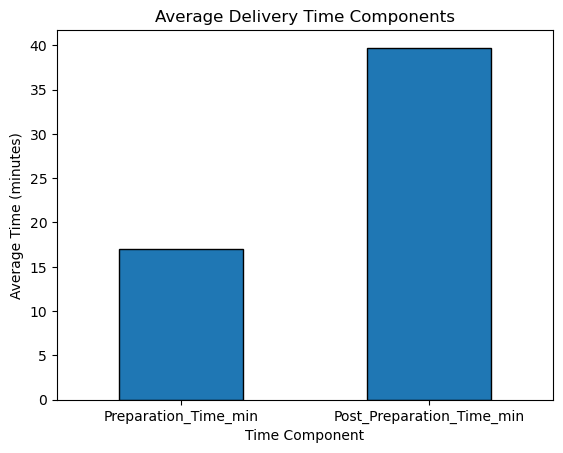

In [76]:
# Calculate average preparation and post-preparation times
time_components = df[
    ['Preparation_Time_min', 'Post_Preparation_Time_min']
].mean()

time_components.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Delivery Time Components')
plt.xlabel('Time Component')
plt.ylabel('Average Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 75. Comparing Post-Preparation Time Across Traffic and Distance

We compare average post-preparation delivery time across traffic levels and distance ranges to examine whether the observed post-preparation delays vary under different combinations of traffic conditions and delivery distance.

In [77]:
# Compare average post-preparation time by traffic level and distance range
df.groupby(
    ['Traffic_Level', 'Distance_Range'],
    observed=True
)['Post_Preparation_Time_min'].mean()

Traffic_Level  Distance_Range
High           0-5 km            24.553191
               5-10 km           39.581395
               10-15 km          53.611111
               15-20 km          70.169811
Low            0-5 km            13.329670
               5-10 km           27.463918
               10-15 km          41.988764
               15-20 km          57.009434
Medium         0-5 km            17.863636
               5-10 km           31.950495
               10-15 km          47.914530
               15-20 km          63.315217
Name: Post_Preparation_Time_min, dtype: float64

### 76. Visualizing Post-Preparation Time by Traffic and Distance

We visualize average post-preparation delivery time across distance ranges and traffic levels to examine how these two factors are associated with differences in post-preparation delivery time.

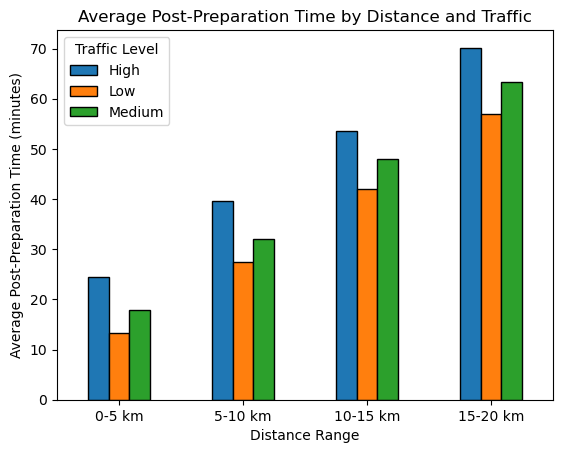

In [78]:
# Plot average post-preparation time by distance range and traffic level
df.groupby(
    ['Distance_Range', 'Traffic_Level'],
    observed=True
)['Post_Preparation_Time_min'].mean().unstack().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Distance and Traffic')
plt.xlabel('Distance Range')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.legend(title='Traffic Level')
plt.show()

### 77. Identifying the Highest Post-Preparation Time Combination

We identify the combination of traffic level and distance range with the highest observed average post-preparation delivery time.

In [79]:
# Identify the traffic and distance combination with the highest average post-preparation time
post_preparation_by_conditions = df.groupby(
    ['Traffic_Level', 'Distance_Range'],
    observed=True
)['Post_Preparation_Time_min'].mean()

post_preparation_by_conditions.idxmax(), post_preparation_by_conditions.max()

(('High', '15-20 km'), 70.16981132075472)

### 78. Calculating the Overall Average Post-Preparation Time

We calculate the overall average post-preparation delivery time to use as a baseline for comparing different traffic and distance conditions.

In [80]:
# Calculate the overall average post-preparation time
overall_post_preparation_mean = df['Post_Preparation_Time_min'].mean()

overall_post_preparation_mean

39.75

### 79. Calculating Deviation from the Overall Baseline

We calculate the difference between the average post-preparation delivery time for each traffic and distance combination and the overall average post-preparation time.

In [81]:
# Calculate the deviation from the overall post-preparation baseline
post_preparation_by_conditions - overall_post_preparation_mean

Traffic_Level  Distance_Range
High           0-5 km           -15.196809
               5-10 km           -0.168605
               10-15 km          13.861111
               15-20 km          30.419811
Low            0-5 km           -26.420330
               5-10 km          -12.286082
               10-15 km           2.238764
               15-20 km          17.259434
Medium         0-5 km           -21.886364
               5-10 km           -7.799505
               10-15 km           8.164530
               15-20 km          23.565217
Name: Post_Preparation_Time_min, dtype: float64

### 80. Identifying Conditions Above the Baseline

We identify the traffic and distance combinations whose average post-preparation delivery time is above the overall baseline.

In [82]:
# Identify conditions with above-baseline post-preparation time
above_baseline = post_preparation_by_conditions[
    post_preparation_by_conditions > overall_post_preparation_mean
]

above_baseline

Traffic_Level  Distance_Range
High           10-15 km          53.611111
               15-20 km          70.169811
Low            10-15 km          41.988764
               15-20 km          57.009434
Medium         10-15 km          47.914530
               15-20 km          63.315217
Name: Post_Preparation_Time_min, dtype: float64

### 81. Calculating the Percentage Above the Baseline

We calculate how much each traffic and distance condition differs from the overall baseline as a percentage.

In [83]:
# Calculate percentage deviation from the overall baseline
percentage_above_baseline = (
    (post_preparation_by_conditions - overall_post_preparation_mean)
    / overall_post_preparation_mean
) * 100

percentage_above_baseline

Traffic_Level  Distance_Range
High           0-5 km           -38.230965
               5-10 km           -0.424163
               10-15 km          34.870720
               15-20 km          76.527827
Low            0-5 km           -66.466238
               5-10 km          -30.908384
               10-15 km           5.632111
               15-20 km          43.419960
Medium         0-5 km           -55.060034
               5-10 km          -19.621396
               10-15 km          20.539698
               15-20 km          59.283566
Name: Post_Preparation_Time_min, dtype: float64

### 82. Sorting Conditions by Post-Preparation Time

We sort the traffic and distance combinations by their average post-preparation delivery time to identify the conditions with the highest observed values.

In [84]:
# Sort traffic and distance conditions by average post-preparation time
post_preparation_by_conditions.sort_values(ascending=False)

Traffic_Level  Distance_Range
High           15-20 km          70.169811
Medium         15-20 km          63.315217
Low            15-20 km          57.009434
High           10-15 km          53.611111
Medium         10-15 km          47.914530
Low            10-15 km          41.988764
High           5-10 km           39.581395
Medium         5-10 km           31.950495
Low            5-10 km           27.463918
High           0-5 km            24.553191
Medium         0-5 km            17.863636
Low            0-5 km            13.329670
Name: Post_Preparation_Time_min, dtype: float64

### 83. Calculating the Increase Across Distance Ranges

We calculate the change in average post-preparation delivery time between the shortest and longest distance ranges for each traffic level.

In [85]:
# Calculate the increase from the shortest to the longest distance range
distance_effect = (
    post_preparation_by_conditions
    .unstack()['15-20 km']
    - post_preparation_by_conditions.unstack()['0-5 km']
)

distance_effect

Traffic_Level
High      45.616620
Low       43.679764
Medium    45.451581
dtype: float64

### 84. Calculating the Increase Across Traffic Levels

We calculate the change in average post-preparation delivery time between the lowest and highest traffic levels within each distance range.

In [86]:
# Calculate the increase from low to high traffic for each distance range
traffic_effect = (
    post_preparation_by_conditions
    .unstack(level='Traffic_Level')
    ['High']
    - post_preparation_by_conditions
    .unstack(level='Traffic_Level')
    ['Low']
)

traffic_effect

Distance_Range
0-5 km      11.223521
5-10 km     12.117478
10-15 km    11.622347
15-20 km    13.160377
dtype: float64

### 85. Creating a Summary of Distance and Traffic Effects

We summarize the observed changes in post-preparation delivery time associated with distance and traffic conditions.

In [87]:
# Check the number of values in each effect calculation
print("Distance effect:", len(distance_effect))
print("Traffic effect:", len(traffic_effect))

Distance effect: 3
Traffic effect: 4


In [88]:
# Calculate the increase from the shortest to the longest distance range
distance_effect = (
    post_preparation_by_conditions
    .unstack(level='Distance_Range')
    ['15-20 km']
    - post_preparation_by_conditions
    .unstack(level='Distance_Range')
    ['0-5 km']
)

distance_effect

Traffic_Level
High      45.616620
Low       43.679764
Medium    45.451581
dtype: float64

### 85. Creating a Summary of Distance and Traffic Effects

We summarize the observed changes in post-preparation delivery time associated with distance and traffic conditions.

In [89]:
# Display the observed effect of distance within each traffic level
print("Distance Effect:")
print(distance_effect)

print("\nTraffic Effect:")
print(traffic_effect)

Distance Effect:
Traffic_Level
High      45.616620
Low       43.679764
Medium    45.451581
dtype: float64

Traffic Effect:
Distance_Range
0-5 km      11.223521
5-10 km     12.117478
10-15 km    11.622347
15-20 km    13.160377
dtype: float64


### 86. Comparing Distance and Traffic Effects

We compare the observed changes associated with distance and traffic conditions to understand which factor shows a larger difference in post-preparation delivery time.

In [90]:
# Compare the ranges of observed distance and traffic effects
print("Distance effect range:")
print(distance_effect.min(), "to", distance_effect.max())

print("\nTraffic effect range:")
print(traffic_effect.min(), "to", traffic_effect.max())

Distance effect range:
43.679763632593826 to 45.61661983139302

Traffic effect range:
11.223521159691371 to 13.160377358490564


### 87. Identifying the Largest Observed Distance Effect

We identify the traffic level with the largest observed increase in post-preparation delivery time between the shortest and longest distance ranges.

In [91]:
# Identify the traffic level with the largest distance effect
distance_effect.idxmax(), distance_effect.max()

('High', 45.61661983139302)

### 88. Identifying the Largest Observed Traffic Effect

We identify the distance range with the largest observed increase in post-preparation delivery time between low and high traffic levels.

In [92]:
# Identify the distance range with the largest traffic effect
traffic_effect.idxmax(), traffic_effect.max()

('15-20 km', 13.160377358490564)

### 89. Comparing the Largest Distance and Traffic Effects

We compare the largest observed distance effect with the largest observed traffic effect to understand the relative magnitude of these two factors.

In [93]:
# Compare the largest observed distance and traffic effects
largest_distance_effect = distance_effect.max()
largest_traffic_effect = traffic_effect.max()

largest_distance_effect, largest_traffic_effect

(45.61661983139302, 13.160377358490564)

### 90. Calculating the Relative Difference Between Distance and Traffic Effects

We calculate how much larger the largest observed distance effect is compared with the largest observed traffic effect.

In [94]:
# Calculate how much larger the distance effect is than the traffic effect
relative_effect_difference = (
    largest_distance_effect / largest_traffic_effect
)

relative_effect_difference

3.466209105467857

### 91. Creating a Final Effect Summary

We summarize the largest observed changes associated with distance and traffic conditions to support the final bottleneck analysis.

In [95]:
# Create a summary of the largest observed distance and traffic effects
effect_summary = pd.Series({
    'Largest Distance Effect (min)': largest_distance_effect,
    'Largest Traffic Effect (min)': largest_traffic_effect,
    'Distance-to-Traffic Effect Ratio': relative_effect_difference
})

effect_summary

Largest Distance Effect (min)       45.616620
Largest Traffic Effect (min)        13.160377
Distance-to-Traffic Effect Ratio     3.466209
dtype: float64

### 92. Calculating the Average Post-Preparation Time by Distance Range

We calculate the average post-preparation delivery time for each distance range to summarize the observed relationship between delivery distance and post-preparation time.

In [96]:
# Calculate average post-preparation time by distance range
post_preparation_by_distance = (
    df.groupby('Distance_Range', observed=True)['Post_Preparation_Time_min']
    .mean()
)

post_preparation_by_distance

Distance_Range
0-5 km      17.467742
5-10 km     31.506224
10-15 km    47.069231
15-20 km    62.099602
Name: Post_Preparation_Time_min, dtype: float64

### 93. Visualizing Post-Preparation Time by Distance Range

We visualize the average post-preparation delivery time across distance ranges to clearly show the observed increase in post-preparation time as delivery distance increases.

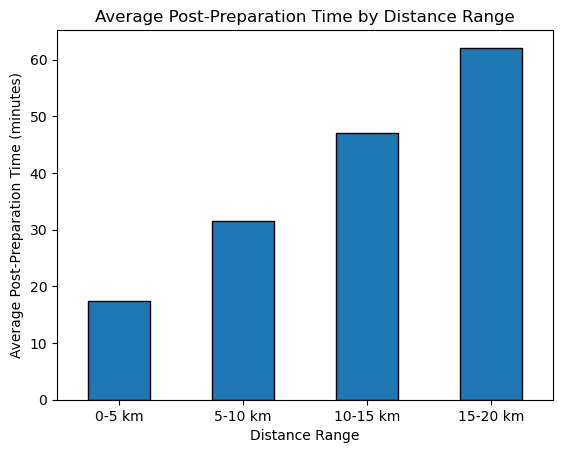

In [97]:
# Plot average post-preparation time by distance range
post_preparation_by_distance.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Distance Range')
plt.xlabel('Distance Range')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 94. Comparing Post-Preparation Time Across Traffic Levels

We calculate the average post-preparation delivery time for each traffic level to summarize the observed relationship between traffic conditions and post-preparation time.

In [98]:
# Calculate average post-preparation time by traffic level
post_preparation_by_traffic = (
    df.groupby('Traffic_Level')['Post_Preparation_Time_min']
    .mean()
)

post_preparation_by_traffic

Traffic_Level
High      48.071066
Low       35.657963
Medium    39.578571
Name: Post_Preparation_Time_min, dtype: float64

### 95. Visualizing Post-Preparation Time by Traffic Level

We visualize the average post-preparation delivery time across traffic levels to clearly show the observed differences between low, medium, and high traffic conditions.

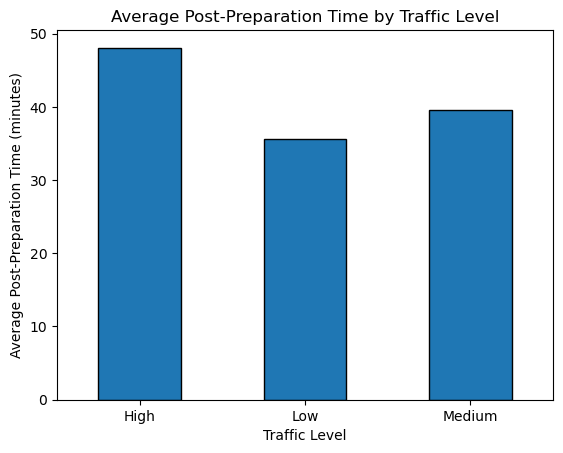

In [99]:
# Plot average post-preparation time by traffic level
post_preparation_by_traffic.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 96. Comparing Post-Preparation Time Across Weather Conditions

We calculate the average post-preparation delivery time for each weather condition to summarize the observed relationship between weather conditions and post-preparation time.

In [102]:
# Calculate average post-preparation time by weather condition
post_preparation_by_weather = (
    df.groupby('Weather')['Post_Preparation_Time_min']
    .mean()
)

post_preparation_by_weather

Weather
Clear    36.074000
Foggy    42.834951
Rainy    42.573529
Snowy    49.711340
Windy    39.520833
Name: Post_Preparation_Time_min, dtype: float64

### 97. Visualizing Post-Preparation Time by Weather

We visualize the average post-preparation delivery time across weather conditions to clearly show the observed differences between weather categories.

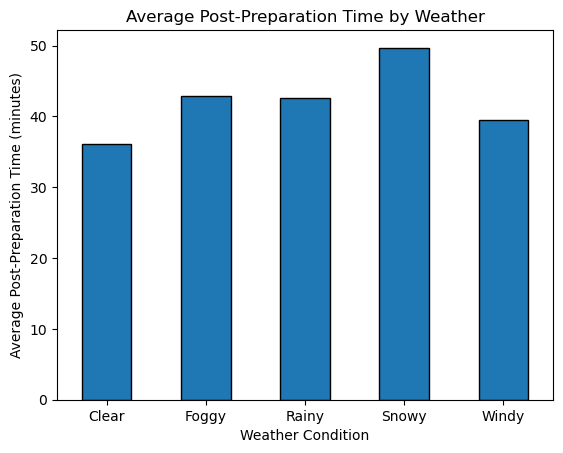

In [104]:
# Plot average post-preparation time by weather condition
post_preparation_by_weather.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Weather')
plt.xlabel('Weather Condition')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 98. Comparing Post-Preparation Time Across Vehicle Types

We calculate the average post-preparation delivery time for each vehicle type to summarize the observed relationship between vehicle type and post-preparation time.

In [106]:
# Calculate average post-preparation time by vehicle type
post_preparation_by_vehicle = (
    df.groupby('Vehicle_Type')['Post_Preparation_Time_min']
    .mean()
)

post_preparation_by_vehicle

Vehicle_Type
Bike       39.723658
Car        41.210256
Scooter    38.850993
Name: Post_Preparation_Time_min, dtype: float64

### 99. Visualizing Post-Preparation Time by Vehicle Type

We visualize the average post-preparation delivery time across vehicle types to clearly show the observed differences between delivery vehicles.

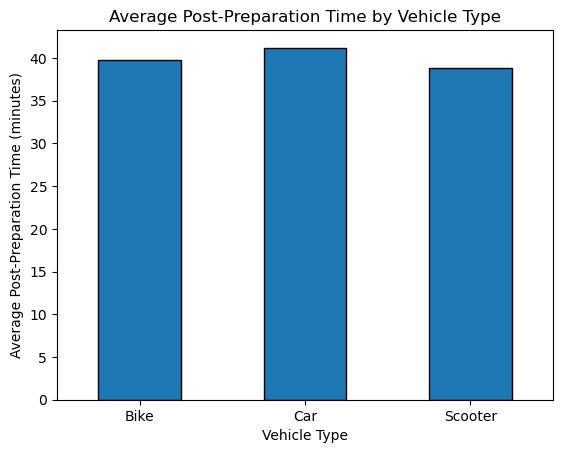

In [107]:
# Plot average post-preparation time by vehicle type
post_preparation_by_vehicle.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 100. Comparing Post-Preparation Time Across Times of Day

We calculate the average post-preparation delivery time for each time-of-day category to summarize the observed relationship between time of day and post-preparation time.

In [108]:
# Calculate average post-preparation time by time of day
post_preparation_by_time = (
    df.groupby('Time_of_Day')['Post_Preparation_Time_min']
    .mean()
)

post_preparation_by_time

Time_of_Day
Afternoon    39.281690
Evening      40.068259
Morning      40.292899
Night        38.058824
Name: Post_Preparation_Time_min, dtype: float64

### 101. Visualizing Post-Preparation Time Across Times of Day

We visualize the average post-preparation delivery time across different times of day to clearly show the observed differences between time-of-day categories.

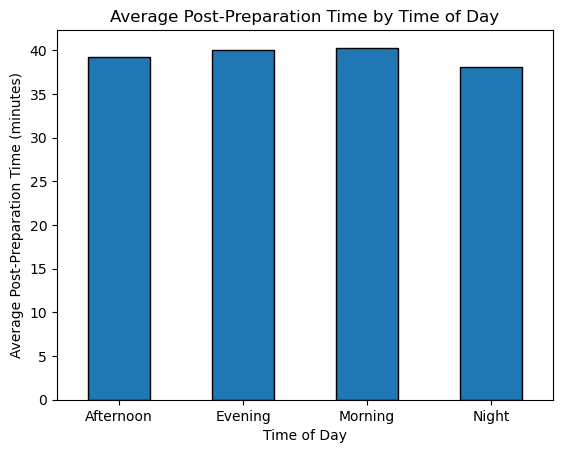

In [109]:
# Plot average post-preparation time by time of day
post_preparation_by_time.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 102. Comparing Post-Preparation Time Across Courier Experience Levels

We calculate the average post-preparation delivery time for each courier experience level to summarize the observed relationship between courier experience and post-preparation time.

In [110]:
# Calculate average post-preparation time by courier experience
post_preparation_by_experience = (
    df.groupby('Courier_Experience_yrs')['Post_Preparation_Time_min']
    .mean()
)

post_preparation_by_experience

Courier_Experience_yrs
0.0    42.516484
1.0    43.392523
2.0    38.000000
3.0    42.287500
4.0    41.478723
5.0    38.033333
6.0    40.165138
7.0    37.725275
8.0    38.356436
9.0    36.527778
Name: Post_Preparation_Time_min, dtype: float64

### 103. Visualizing Post-Preparation Time Across Courier Experience Levels

We visualize the average post-preparation delivery time across different courier experience levels to better understand the observed variation across experience levels.

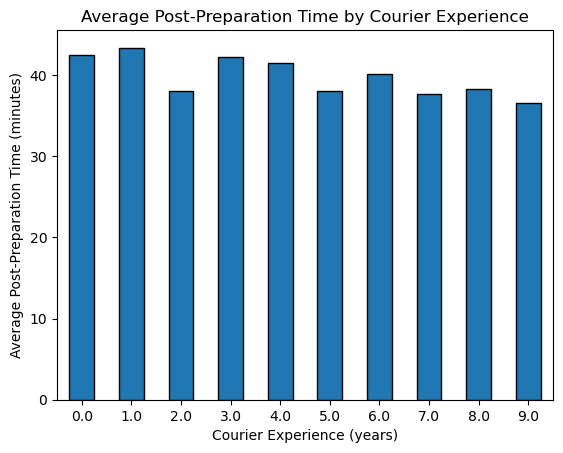

In [111]:
# Plot average post-preparation time by courier experience
post_preparation_by_experience.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Courier Experience')
plt.xlabel('Courier Experience (years)')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.show()

### 104. Comparing Post-Preparation Time by Distance and Traffic

We summarize average post-preparation delivery time across distance ranges and traffic levels to examine how these two conditions jointly relate to post-preparation delivery time.

In [112]:
# Create a table of average post-preparation time by distance and traffic
post_preparation_distance_traffic = (
    df.groupby(
        ['Distance_Range', 'Traffic_Level'],
        observed=True
    )['Post_Preparation_Time_min']
    .mean()
    .unstack()
)

post_preparation_distance_traffic

Traffic_Level,High,Low,Medium
Distance_Range,,,
0-5 km,24.553191,13.329670,17.863636
5-10 km,39.581395,27.463918,31.950495
10-15 km,53.611111,41.988764,47.914530
15-20 km,70.169811,57.009434,63.315217


### 105. Visualizing Post-Preparation Time by Distance and Traffic

We visualize average post-preparation delivery time across distance ranges and traffic levels to clearly show how these two conditions are associated with differences in post-preparation delivery time.

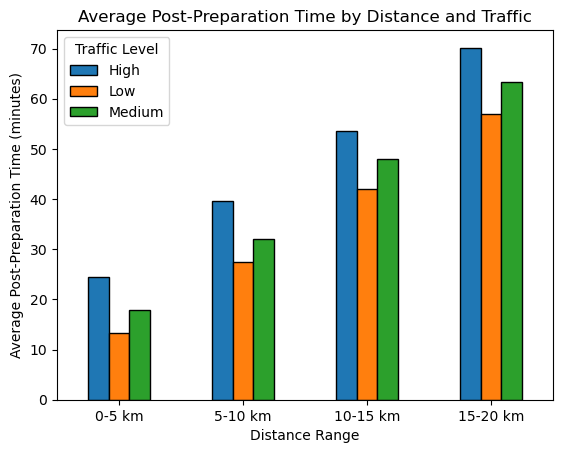

In [113]:
# Plot average post-preparation time by distance range and traffic level
post_preparation_distance_traffic.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Post-Preparation Time by Distance and Traffic')
plt.xlabel('Distance Range')
plt.ylabel('Average Post-Preparation Time (minutes)')
plt.xticks(rotation=0)
plt.legend(title='Traffic Level')
plt.show()

### 106. Identifying the Highest Post-Preparation Time Condition

We identify the distance and traffic combination with the highest observed average post-preparation delivery time.

In [114]:
# Identify the condition with the highest average post-preparation time
highest_condition = post_preparation_distance_traffic.stack().idxmax()
highest_value = post_preparation_distance_traffic.stack().max()

highest_condition, highest_value

(('15-20 km', 'High'), 70.16981132075472)

### 107. Calculating the Overall Average Post-Preparation Time

We calculate the overall average post-preparation delivery time to use as a baseline for comparing different distance and traffic conditions.

In [115]:
# Calculate the overall average post-preparation time
overall_post_preparation_mean = df['Post_Preparation_Time_min'].mean()

overall_post_preparation_mean

39.75

### 108. Calculating Deviation from the Overall Baseline

We calculate the difference between the average post-preparation delivery time for each distance and traffic condition and the overall average post-preparation time.

In [116]:
# Calculate deviation from the overall post-preparation baseline
post_preparation_deviation = (
    post_preparation_distance_traffic
    - overall_post_preparation_mean
)

post_preparation_deviation

Traffic_Level,High,Low,Medium
Distance_Range,,,
0-5 km,-15.196809,-26.420330,-21.886364
5-10 km,-0.168605,-12.286082,-7.799505
10-15 km,13.861111,2.238764,8.164530
15-20 km,30.419811,17.259434,23.565217


### 109. Identifying Conditions Above the Baseline

We identify the distance and traffic conditions whose average post-preparation delivery time is above the overall baseline.

In [117]:
# Identify conditions with above-baseline post-preparation time
above_baseline_conditions = post_preparation_distance_traffic[
    post_preparation_distance_traffic > overall_post_preparation_mean
]

above_baseline_conditions

Traffic_Level,High,Low,Medium
Distance_Range,,,
0-5 km,NaN,NaN,NaN
5-10 km,NaN,NaN,NaN
10-15 km,53.611111,41.988764,47.914530
15-20 km,70.169811,57.009434,63.315217


### 110. Calculating the Percentage Deviation from the Baseline

We calculate the percentage deviation of each distance and traffic condition from the overall post-preparation baseline.

In [118]:
# Calculate percentage deviation from the overall post-preparation baseline
percentage_deviation = (
    (post_preparation_distance_traffic - overall_post_preparation_mean)
    / overall_post_preparation_mean
) * 100

percentage_deviation

Traffic_Level,High,Low,Medium
Distance_Range,,,
0-5 km,-38.230965,-66.466238,-55.060034
5-10 km,-0.424163,-30.908384,-19.621396
10-15 km,34.870720,5.632111,20.539698
15-20 km,76.527827,43.419960,59.283566


### 111. Identifying the Highest Percentage Deviation

We identify the distance and traffic condition with the highest percentage deviation from the overall post-preparation baseline.

In [119]:
# Identify the condition with the highest percentage deviation
highest_percentage_condition = percentage_deviation.stack().idxmax()
highest_percentage_value = percentage_deviation.stack().max()

highest_percentage_condition, highest_percentage_value

(('15-20 km', 'High'), 76.52782722202444)

### 112. Sorting Conditions by Post-Preparation Time

We sort the distance and traffic conditions by their average post-preparation delivery time to identify the conditions with the highest observed values.

In [120]:
# Sort conditions by average post-preparation time
sorted_post_preparation_conditions = (
    post_preparation_distance_traffic
    .stack()
    .sort_values(ascending=False)
)

sorted_post_preparation_conditions

Distance_Range  Traffic_Level
15-20 km        High             70.169811
                Medium           63.315217
                Low              57.009434
10-15 km        High             53.611111
                Medium           47.914530
                Low              41.988764
5-10 km         High             39.581395
                Medium           31.950495
                Low              27.463918
0-5 km          High             24.553191
                Medium           17.863636
                Low              13.329670
dtype: float64

### 113. Calculating the Distance Effect Across Traffic Levels

We calculate the increase in average post-preparation delivery time between the shortest and longest distance ranges for each traffic level.

In [121]:
# Calculate the increase from the shortest to the longest distance range
distance_effect = (
    post_preparation_distance_traffic
    .loc['15-20 km']
    - post_preparation_distance_traffic
    .loc['0-5 km']
)

distance_effect

Traffic_Level
High      45.616620
Low       43.679764
Medium    45.451581
dtype: float64

### 114. Calculating the Traffic Effect Across Distance Ranges

We calculate the increase in average post-preparation delivery time between low and high traffic levels for each distance range.

In [122]:
# Calculate the increase from low to high traffic for each distance range
traffic_effect = (
    post_preparation_distance_traffic['High']
    - post_preparation_distance_traffic['Low']
)

traffic_effect

Distance_Range
0-5 km      11.223521
5-10 km     12.117478
10-15 km    11.622347
15-20 km    13.160377
dtype: float64

### 115. Creating a Summary of Distance and Traffic Effects

We summarize the observed changes in post-preparation delivery time associated with distance and traffic conditions.

# Display the observed effects of distance and traffic
print("Distance Effect:")
print(distance_effect)

print("\nTraffic Effect:")
print(traffic_effect)

### 116. Comparing Distance and Traffic Effects

We compare the ranges of the observed distance and traffic effects to understand the relative magnitude of these two factors.

In [124]:
# Compare the ranges of observed distance and traffic effects
print("Distance effect range:")
print(distance_effect.min(), "to", distance_effect.max())

print("\nTraffic effect range:")
print(traffic_effect.min(), "to", traffic_effect.max())

Distance effect range:
43.679763632593826 to 45.61661983139302

Traffic effect range:
11.223521159691371 to 13.160377358490564


### 117. Identifying the Largest Observed Distance Effect

We identify the traffic level with the largest observed increase in post-preparation delivery time between the shortest and longest distance ranges.

In [127]:
# Identify the traffic level with the largest distance effect
largest_distance_condition = distance_effect.idxmax()
largest_distance_effect = distance_effect.max()

largest_distance_condition, largest_distance_effect

('High', 45.61661983139302)

### 118. Identifying the Largest Observed Traffic Effect

We identify the distance range with the largest observed increase in post-preparation delivery time between low and high traffic levels.

In [128]:
# Identify the distance range with the largest traffic effect
largest_traffic_condition = traffic_effect.idxmax()
largest_traffic_effect = traffic_effect.max()

largest_traffic_condition, largest_traffic_effect

('15-20 km', 13.160377358490564)

### 119. Comparing the Largest Observed Distance and Traffic Effects

We compare the largest observed distance effect with the largest observed traffic effect to understand the relative magnitude of these two factors.

In [129]:
# Compare the largest observed distance and traffic effects
largest_distance_effect, largest_traffic_effect

(45.61661983139302, 13.160377358490564)

### 120. Calculating the Relative Difference Between Distance and Traffic Effects

We calculate how many times larger the largest observed distance effect is compared with the largest observed traffic effect.

In [130]:
# Calculate how many times larger the distance effect is than the traffic effect
relative_effect_difference = (
    largest_distance_effect / largest_traffic_effect
)

relative_effect_difference

3.466209105467857

### 121. Creating a Final Effect Summary

We summarize the largest observed changes associated with distance and traffic conditions to support the final bottleneck analysis.

In [131]:
# Create a summary of the largest observed distance and traffic effects
effect_summary = pd.Series({
    'Largest Distance Effect (min)': largest_distance_effect,
    'Largest Traffic Effect (min)': largest_traffic_effect,
    'Distance-to-Traffic Effect Ratio': relative_effect_difference
})

effect_summary

Largest Distance Effect (min)       45.616620
Largest Traffic Effect (min)        13.160377
Distance-to-Traffic Effect Ratio     3.466209
dtype: float64

### 122. Summarizing the Observed Distance Effect

We summarize the average post-preparation delivery time across distance ranges to clearly describe the observed relationship between delivery distance and post-preparation time.

In [132]:
# Display average post-preparation time by distance range
post_preparation_by_distance

Distance_Range
0-5 km      17.467742
5-10 km     31.506224
10-15 km    47.069231
15-20 km    62.099602
Name: Post_Preparation_Time_min, dtype: float64

### 123. Summarizing the Observed Traffic Effect

We summarize the average post-preparation delivery time across traffic levels to describe the observed relationship between traffic conditions and post-preparation time.

In [133]:
# Display average post-preparation time by traffic level
post_preparation_by_traffic

Traffic_Level
High      48.071066
Low       35.657963
Medium    39.578571
Name: Post_Preparation_Time_min, dtype: float64

### 124. Comparing Distance and Traffic Effects

We compare the observed changes in post-preparation delivery time associated with distance and traffic conditions to support the final bottleneck analysis.

In [134]:
# Compare the largest observed distance and traffic effects
effect_comparison = pd.Series({
    'Distance Effect (min)': largest_distance_effect,
    'Traffic Effect (min)': largest_traffic_effect
})

effect_comparison

Distance Effect (min)    45.616620
Traffic Effect (min)     13.160377
dtype: float64

### 125. Calculating the Relative Magnitude of Distance and Traffic Effects

We calculate the ratio between the largest observed distance effect and the largest observed traffic effect to quantify their relative magnitude.

In [135]:
# Calculate the ratio between the largest distance and traffic effects
distance_traffic_ratio = (
    largest_distance_effect / largest_traffic_effect
)

distance_traffic_ratio

3.466209105467857

### 126. Calculating the Increase in Post-Preparation Time Across Distance Ranges

We calculate the change in average post-preparation delivery time between consecutive distance ranges to examine how the observed time increases as distance grows.

In [136]:
# Calculate the change in average post-preparation time between consecutive distance ranges
distance_range_change = post_preparation_by_distance.diff()

distance_range_change

Distance_Range
0-5 km            NaN
5-10 km     14.038482
10-15 km    15.563007
15-20 km    15.030371
Name: Post_Preparation_Time_min, dtype: float64

### 127. Identifying the Largest Increase Across Distance Ranges

We identify the distance transition with the largest observed increase in average post-preparation delivery time.

In [137]:
# Identify the largest increase between consecutive distance ranges
largest_distance_range_increase = distance_range_change.max()
largest_distance_range_increase_range = distance_range_change.idxmax()

largest_distance_range_increase_range, largest_distance_range_increase

('10-15 km', 15.563006702840728)

### 128. Summarizing the Distance-Based Findings

We summarize the observed distance-based changes in post-preparation delivery time to support the final bottleneck analysis.

In [138]:
# Create a summary of the main distance-based findings
distance_summary = pd.Series({
    'Shortest Range Mean (min)': post_preparation_by_distance.loc['0-5 km'],
    'Longest Range Mean (min)': post_preparation_by_distance.loc['15-20 km'],
    'Largest Distance Effect (min)': largest_distance_effect,
    'Largest Consecutive Increase (min)': largest_distance_range_increase
})

distance_summary

Shortest Range Mean (min)             17.467742
Longest Range Mean (min)              62.099602
Largest Distance Effect (min)         45.616620
Largest Consecutive Increase (min)    15.563007
dtype: float64

### 129. Summarizing the Traffic-Based Findings

We summarize the observed traffic-based changes in post-preparation delivery time to support the final bottleneck analysis.

In [139]:
# Create a summary of the main traffic-based findings
traffic_summary = pd.Series({
    'Low Traffic Mean (min)': post_preparation_by_traffic.loc['Low'],
    'High Traffic Mean (min)': post_preparation_by_traffic.loc['High'],
    'Largest Traffic Effect (min)': largest_traffic_effect
})

traffic_summary

Low Traffic Mean (min)          35.657963
High Traffic Mean (min)         48.071066
Largest Traffic Effect (min)    13.160377
dtype: float64

### 130. Creating a Combined Distance and Traffic Summary

We combine the main distance- and traffic-based findings into a single summary for the final bottleneck analysis.

In [140]:
# Combine the main distance- and traffic-based findings
combined_effect_summary = pd.DataFrame({
    'Distance': distance_summary,
    'Traffic': traffic_summary
})

combined_effect_summary

,Distance,Traffic
High Traffic Mean (min),NaN,48.071066
Largest Consecutive Increase (min),15.563007,NaN
Largest Distance Effect (min),45.616620,NaN
Largest Traffic Effect (min),NaN,13.160377
Longest Range Mean (min),62.099602,NaN
Low Traffic Mean (min),NaN,35.657963
Shortest Range Mean (min),17.467742,NaN


### 131. Creating the Final Analysis Summary

We combine the main delivery-time, post-preparation, distance, and traffic findings into a final summary for the bottleneck analysis.

In [141]:
# Create a final summary of the main analysis findings
final_analysis_summary = pd.Series({
    'Average Delivery Time (min)': df['Delivery_Time_min'].mean(),
    'Average Preparation Time (min)': df['Preparation_Time_min'].mean(),
    'Average Post-Preparation Time (min)': df['Post_Preparation_Time_min'].mean(),
    'Average Post-Preparation Share (%)': post_preparation_share * 100,
    'Largest Distance Effect (min)': largest_distance_effect,
    'Largest Traffic Effect (min)': largest_traffic_effect,
    'Distance-to-Traffic Effect Ratio': distance_traffic_ratio,
    'Highest Post-Preparation Condition (min)': highest_value
})

final_analysis_summary

Average Delivery Time (min)                 56.732000
Average Preparation Time (min)              16.982000
Average Post-Preparation Time (min)         39.750000
Average Post-Preparation Share (%)          66.728722
Largest Distance Effect (min)               45.616620
Largest Traffic Effect (min)                13.160377
Distance-to-Traffic Effect Ratio             3.466209
Highest Post-Preparation Condition (min)    70.169811
dtype: float64

### 132. Organizing the Final Analysis Findings

We organize the main analysis findings into a structured table for easier interpretation and reporting.

In [142]:
# Convert the final analysis summary into a structured table
final_analysis_table = final_analysis_summary.to_frame(name='Value')

final_analysis_table

,Value
Average Delivery Time (min),56.732000
Average Preparation Time (min),16.982000
Average Post-Preparation Time (min),39.750000
Average Post-Preparation Share (%),66.728722
Largest Distance Effect (min),45.616620
Largest Traffic Effect (min),13.160377
Distance-to-Traffic Effect Ratio,3.466209
Highest Post-Preparation Condition (min),70.169811


### 133. Verifying Derived Analysis Columns

We verify that the derived columns used in the analysis are present and contain no missing values before completing the analysis.

In [143]:
# Check the derived analysis columns for missing values
df[['Distance_Range', 'Post_Preparation_Time_min']].isnull().sum()

Distance_Range               0
Post_Preparation_Time_min    0
dtype: int64

### 134. Verifying the Final Dataset Structure

We verify the final number of rows and columns after completing the data cleaning and analysis steps.

In [144]:
# Check the final number of rows and columns
df.shape

(1000, 11)

### 135. Final Missing Value Check

We perform a final check for missing values to confirm that the cleaned dataset is complete before the final analysis.

In [145]:
# Check for any remaining missing values in the final dataset
df.isnull().sum().sum()

0

### 136. Final Duplicate Check

We perform a final check for duplicate rows to confirm that the cleaned dataset does not contain repeated records.

In [146]:
# Check for duplicate rows in the final dataset
df.duplicated().sum()

0

### 137. Final Order ID Uniqueness Check

We perform a final check to confirm that each order has a unique `Order_ID` in the final dataset.

In [147]:
# Check for duplicate Order_ID values in the final dataset
df['Order_ID'].duplicated().sum()

0

### 138. Final Numeric Range Check

We perform a final range check on the main numeric variables to confirm that the cleaned dataset contains values within the observed valid ranges.

In [148]:
# Check the final minimum and maximum values of the main numeric variables
df[
    [
        'Distance_km',
        'Preparation_Time_min',
        'Courier_Experience_yrs',
        'Delivery_Time_min',
        'Post_Preparation_Time_min'
    ]
].agg(['min', 'max'])

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Post_Preparation_Time_min
min,0.59,5,0.0,8,2
max,19.99,29,9.0,153,124


### 139. Final Post-Preparation Consistency Check

We verify that the derived `Post_Preparation_Time_min` is always non-negative and consistent with the overall delivery duration.

In [149]:
# Check for negative post-preparation time values
(df['Post_Preparation_Time_min'] < 0).sum()

0

### 140. Final Delivery Time Consistency Check

We verify that the overall delivery time is equal to the sum of preparation time and post-preparation time for every order.

In [150]:
# Verify that delivery time equals preparation time plus post-preparation time
(
    df['Preparation_Time_min']
    + df['Post_Preparation_Time_min']
    == df['Delivery_Time_min']
).all()

True

### 141. Comparing Preparation and Post-Preparation Time

We compare the average preparation time with the average post-preparation time to summarize the contribution of each stage to the overall delivery duration.

In [151]:
# Compare the average preparation and post-preparation times
stage_time_summary = pd.Series({
    'Preparation Time (min)': df['Preparation_Time_min'].mean(),
    'Post-Preparation Time (min)': df['Post_Preparation_Time_min'].mean()
})

stage_time_summary

Preparation Time (min)         16.982
Post-Preparation Time (min)    39.750
dtype: float64

### 142. Calculating the Average Time Share by Stage

We calculate the share of the average delivery duration represented by preparation and post-preparation time.

In [152]:
# Calculate the share of each stage in the average delivery duration
stage_time_share = (
    stage_time_summary / df['Delivery_Time_min'].mean()
) * 100

stage_time_share

Preparation Time (min)         29.933723
Post-Preparation Time (min)    70.066277
dtype: float64

### 143. Summarizing Stage Contributions

We summarize the contribution of preparation and post-preparation time to the average delivery duration.

In [153]:
# Create a summary of the average stage contributions
stage_contribution_summary = pd.Series({
    'Preparation Share (%)': stage_time_share['Preparation Time (min)'],
    'Post-Preparation Share (%)': stage_time_share['Post-Preparation Time (min)']
})

stage_contribution_summary

Preparation Share (%)         29.933723
Post-Preparation Share (%)    70.066277
dtype: float64

### 144. Comparing Post-Preparation Share Across Distance Ranges

We compare the average share of post-preparation time across distance ranges to examine whether the post-preparation contribution changes with delivery distance.

In [155]:
# Calculate the average post-preparation share for each distance range
post_preparation_share_by_distance = (
    df.groupby('Distance_Range', observed=True)[
        ['Post_Preparation_Time_min', 'Delivery_Time_min']
    ]
    .apply(
        lambda group: (
            group['Post_Preparation_Time_min']
            / group['Delivery_Time_min']
        ).mean()
    ) * 100
)

post_preparation_share_by_distance

Distance_Range
0-5 km      49.764636
5-10 km     63.928092
10-15 km    74.379910
15-20 km    78.253568
dtype: float64

### 145. Identifying the Largest Increase in Post-Preparation Share

We identify the distance transition with the largest observed increase in the share of post-preparation delivery time.

In [156]:
# Calculate the change in post-preparation share between consecutive distance ranges
post_preparation_share_change = post_preparation_share_by_distance.diff()

post_preparation_share_change

Distance_Range
0-5 km            NaN
5-10 km     14.163456
10-15 km    10.451818
15-20 km     3.873658
dtype: float64

### 146. Identifying the Largest Increase in Post-Preparation Share

We identify the distance transition with the largest increase in the observed post-preparation share.

In [157]:
# Identify the largest increase in post-preparation share
largest_share_increase = post_preparation_share_change.max()
largest_share_increase_range = post_preparation_share_change.idxmax()

largest_share_increase_range, largest_share_increase

('5-10 km', 14.163456264621068)

### 147. Summarizing Post-Preparation Share Findings

We summarize the main observed changes in post-preparation share across distance ranges to support the final bottleneck analysis.

In [158]:
# Create a summary of the main post-preparation share findings
post_preparation_share_summary = pd.Series({
    'Shortest Range Share (%)': post_preparation_share_by_distance.loc['0-5 km'],
    'Longest Range Share (%)': post_preparation_share_by_distance.loc['15-20 km'],
    'Largest Share Increase (percentage points)': largest_share_increase
})

post_preparation_share_summary

Shortest Range Share (%)                      49.764636
Longest Range Share (%)                       78.253568
Largest Share Increase (percentage points)    14.163456
dtype: float64

### 148. Comparing Post-Preparation Share Across Traffic Levels

We compare the average share of post-preparation time across traffic levels to examine whether traffic conditions are associated with differences in the post-preparation contribution.

In [160]:
# Calculate the average post-preparation share for each traffic level
post_preparation_share_by_traffic = (
    df.groupby('Traffic_Level')[
        ['Post_Preparation_Time_min', 'Delivery_Time_min']
    ]
    .apply(
        lambda group: (
            group['Post_Preparation_Time_min']
            / group['Delivery_Time_min']
        ).mean()
    ) * 100
)

post_preparation_share_by_traffic

Traffic_Level
High      71.845467
Low       63.540445
Medium    67.236130
dtype: float64

### 149. Calculating the Traffic-Based Share Difference

We calculate the difference in the observed post-preparation share between low and high traffic levels.

In [161]:
# Calculate the difference between high and low traffic post-preparation shares
traffic_share_difference = (
    post_preparation_share_by_traffic['High']
    - post_preparation_share_by_traffic['Low']
)

traffic_share_difference

8.3050220021196

### 150. Summarizing Traffic-Based Share Findings

We summarize the main observed differences in post-preparation share across traffic levels to support the final bottleneck analysis.

In [162]:
# Create a summary of the main traffic-based share findings
traffic_share_summary = pd.Series({
    'Low Traffic Share (%)': post_preparation_share_by_traffic['Low'],
    'High Traffic Share (%)': post_preparation_share_by_traffic['High'],
    'High-Low Share Difference (percentage points)': traffic_share_difference
})

traffic_share_summary

Low Traffic Share (%)                            63.540445
High Traffic Share (%)                           71.845467
High-Low Share Difference (percentage points)     8.305022
dtype: float64

### 151. Comparing Post-Preparation Share by Distance and Traffic

We compare the average post-preparation share across distance ranges and traffic levels to examine how these conditions jointly relate to the post-preparation contribution.

In [164]:
# Calculate average post-preparation share by distance range and traffic level
post_preparation_share_distance_traffic = (
    df.groupby(
        ['Distance_Range', 'Traffic_Level'],
        observed=True
    )[
        ['Post_Preparation_Time_min', 'Delivery_Time_min']
    ]
    .apply(
        lambda group: (
            group['Post_Preparation_Time_min']
            / group['Delivery_Time_min']
        ).mean() * 100
    )
    .unstack()
)

post_preparation_share_distance_traffic

Traffic_Level,High,Low,Medium
Distance_Range,,,
0-5 km,57.994107,43.005865,51.839754
5-10 km,68.132453,61.095970,64.858076
10-15 km,77.919176,71.889786,74.640599
15-20 km,80.952887,76.395817,78.838977


### 152. Identifying the Highest and Lowest Post-Preparation Shares

We identify the distance and traffic conditions with the highest and lowest observed post-preparation shares.

In [165]:
# Identify the highest and lowest observed post-preparation shares
highest_share_condition = post_preparation_share_distance_traffic.stack().idxmax()
highest_share_value = post_preparation_share_distance_traffic.stack().max()

lowest_share_condition = post_preparation_share_distance_traffic.stack().idxmin()
lowest_share_value = post_preparation_share_distance_traffic.stack().min()

highest_share_condition, highest_share_value, lowest_share_condition, lowest_share_value

(('15-20 km', 'High'),
 80.95288740967916,
 ('0-5 km', 'Low'),
 43.005865295425195)

### 153. Calculating the Range of Post-Preparation Shares

We calculate the difference between the highest and lowest observed post-preparation shares across distance and traffic conditions.

In [166]:
# Calculate the range between the highest and lowest post-preparation shares
post_preparation_share_range = (
    highest_share_value - lowest_share_value
)

post_preparation_share_range

37.94702211425397

### 154. Summarizing Distance and Traffic Share Findings

We summarize the main observed post-preparation share findings across distance and traffic conditions for the final bottleneck analysis.

In [167]:
# Create a summary of the main distance and traffic share findings
distance_traffic_share_summary = pd.Series({
    'Lowest Post-Preparation Share (%)': lowest_share_value,
    'Highest Post-Preparation Share (%)': highest_share_value,
    'Share Range (percentage points)': post_preparation_share_range
})

distance_traffic_share_summary

Lowest Post-Preparation Share (%)     43.005865
Highest Post-Preparation Share (%)    80.952887
Share Range (percentage points)       37.947022
dtype: float64

### 155. Summarizing Overall Post-Preparation Share by Distance

We summarize the overall observed post-preparation share across distance ranges without separating the results by traffic level.

In [168]:
# Display the overall post-preparation share by distance range
post_preparation_share_by_distance

Distance_Range
0-5 km      49.764636
5-10 km     63.928092
10-15 km    74.379910
15-20 km    78.253568
dtype: float64

### 156. Summarizing the Overall Distance-Based Share Trend

We summarize the change in post-preparation share between the shortest and longest distance ranges.

In [169]:
# Summarize the change in post-preparation share across distance ranges
distance_share_summary = pd.Series({
    'Shortest Distance Share (%)': post_preparation_share_by_distance.loc['0-5 km'],
    'Longest Distance Share (%)': post_preparation_share_by_distance.loc['15-20 km'],
    'Overall Share Increase (percentage points)': (
        post_preparation_share_by_distance.loc['15-20 km']
        - post_preparation_share_by_distance.loc['0-5 km']
    )
})

distance_share_summary

Shortest Distance Share (%)                   49.764636
Longest Distance Share (%)                    78.253568
Overall Share Increase (percentage points)    28.488932
dtype: float64

### 157. Visualizing Post-Preparation Share by Distance

We visualize the observed post-preparation share across distance ranges to clearly show how the share changes as delivery distance increases.

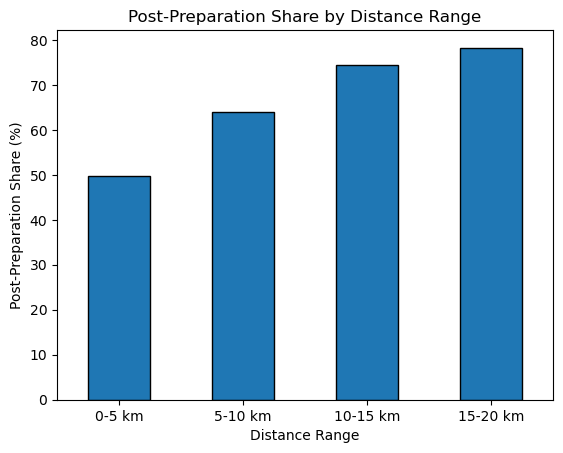

In [170]:
# Plot post-preparation share by distance range
post_preparation_share_by_distance.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Post-Preparation Share by Distance Range')
plt.xlabel('Distance Range')
plt.ylabel('Post-Preparation Share (%)')
plt.xticks(rotation=0)
plt.show()

### 158. Visualizing Post-Preparation Share by Traffic Level

We visualize the observed post-preparation share across traffic levels to clearly show how the share changes under different traffic conditions.

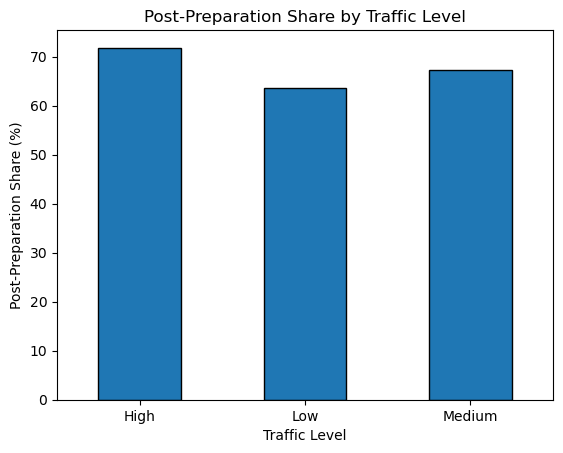

In [171]:
# Plot post-preparation share by traffic level
post_preparation_share_by_traffic.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Post-Preparation Share by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Post-Preparation Share (%)')
plt.xticks(rotation=0)
plt.show()

### 159. Summarizing Traffic-Based Post-Preparation Share

We summarize the observed post-preparation share across traffic levels for the final bottleneck analysis.

In [172]:
# Create a summary of post-preparation share by traffic level
traffic_share_final_summary = pd.Series({
    'Low Traffic Share (%)': post_preparation_share_by_traffic['Low'],
    'Medium Traffic Share (%)': post_preparation_share_by_traffic['Medium'],
    'High Traffic Share (%)': post_preparation_share_by_traffic['High']
})

traffic_share_final_summary

Low Traffic Share (%)       63.540445
Medium Traffic Share (%)    67.236130
High Traffic Share (%)      71.845467
dtype: float64

### 160. Creating the Final Post-Preparation Share Summary

We combine the main distance- and traffic-based post-preparation share findings into a single summary for the final bottleneck analysis.

In [173]:
# Create a final summary of post-preparation share findings
final_share_summary = pd.Series({
    'Shortest Distance Share (%)': post_preparation_share_by_distance.loc['0-5 km'],
    'Longest Distance Share (%)': post_preparation_share_by_distance.loc['15-20 km'],
    'Distance Share Increase (percentage points)': (
        post_preparation_share_by_distance.loc['15-20 km']
        - post_preparation_share_by_distance.loc['0-5 km']
    ),
    'Low Traffic Share (%)': post_preparation_share_by_traffic.loc['Low'],
    'High Traffic Share (%)': post_preparation_share_by_traffic.loc['High'],
    'Traffic Share Increase (percentage points)': traffic_share_difference,
    'Highest Combined Share (%)': highest_share_value,
    'Lowest Combined Share (%)': lowest_share_value,
    'Combined Share Range (percentage points)': post_preparation_share_range
})

final_share_summary

Shortest Distance Share (%)                    49.764636
Longest Distance Share (%)                     78.253568
Distance Share Increase (percentage points)    28.488932
Low Traffic Share (%)                          63.540445
High Traffic Share (%)                         71.845467
Traffic Share Increase (percentage points)      8.305022
Highest Combined Share (%)                     80.952887
Lowest Combined Share (%)                      43.005865
Combined Share Range (percentage points)       37.947022
dtype: float64

### 161. Comparing Post-Preparation Time Across Key Factors

We compare the observed average post-preparation delivery time across the main categorical and operational factors to support the final bottleneck analysis.

In [174]:
# Create a summary table of post-preparation time across key factors
key_factor_summary = pd.DataFrame({
    'Traffic': post_preparation_by_traffic,
    'Weather': post_preparation_by_weather,
    'Vehicle': post_preparation_by_vehicle,
    'Time of Day': post_preparation_by_time
})

key_factor_summary

,Traffic,Weather,Vehicle,Time of Day
Afternoon,NaN,NaN,NaN,39.281690
Bike,NaN,NaN,39.723658,NaN
Car,NaN,NaN,41.210256,NaN
Clear,NaN,36.074000,NaN,NaN
Evening,NaN,NaN,NaN,40.068259
Foggy,NaN,42.834951,NaN,NaN
High,48.071066,NaN,NaN,NaN
Low,35.657963,NaN,NaN,NaN
Medium,39.578571,NaN,NaN,NaN
Morning,NaN,NaN,NaN,40.292899


### 162. Summarizing the Range of Post-Preparation Time Across Key Factors

We summarize the lowest and highest observed average post-preparation delivery times for each key factor.

In [176]:
# Create a clean summary table of the observed ranges across key factors
factor_range_summary = pd.DataFrame({
    'Factor': [
        'Traffic',
        'Weather',
        'Vehicle',
        'Time of Day'
    ],
    'Minimum Mean (min)': [
        post_preparation_by_traffic.min(),
        post_preparation_by_weather.min(),
        post_preparation_by_vehicle.min(),
        post_preparation_by_time.min()
    ],
    'Maximum Mean (min)': [
        post_preparation_by_traffic.max(),
        post_preparation_by_weather.max(),
        post_preparation_by_vehicle.max(),
        post_preparation_by_time.max()
    ]
}).set_index('Factor')

factor_range_summary

,Minimum Mean (min),Maximum Mean (min)
Factor,,
Traffic,35.657963,48.071066
Weather,36.074000,49.711340
Vehicle,38.850993,41.210256
Time of Day,38.058824,40.292899


### 163. Calculating the Range of Post-Preparation Time Across Key Factors

We calculate the observed range of average post-preparation delivery time for each key factor.

In [177]:
# Calculate the observed range for each key factor
factor_range_summary['Range (min)'] = (
    factor_range_summary['Maximum Mean (min)']
    - factor_range_summary['Minimum Mean (min)']
)

factor_range_summary

,Minimum Mean (min),Maximum Mean (min),Range (min)
Factor,,,
Traffic,35.657963,48.071066,12.413103
Weather,36.074000,49.711340,13.637340
Vehicle,38.850993,41.210256,2.359263
Time of Day,38.058824,40.292899,2.234076


## 164. Key Findings

The analysis identified several important patterns in delivery performance.

- The average delivery time is 56.73 minutes, with an average preparation time of 16.98 minutes and an average post-preparation time of 39.75 minutes.
- Post-preparation time represents a substantial portion of the overall delivery duration.
- Delivery distance shows a strong observed association with post-preparation time, increasing from 17.47 minutes for 0–5 km deliveries to 62.10 minutes for 15–20 km deliveries.
- Traffic conditions are also associated with post-preparation time, increasing from 35.66 minutes under low traffic to 48.07 minutes under high traffic.
- The highest observed post-preparation time occurs for deliveries in the 15–20 km range under high traffic, at 70.17 minutes.
- Vehicle type and time of day show smaller differences in average post-preparation time compared with distance and traffic.
- These findings describe observed associations in the dataset and do not establish causation.

## 165. Bottleneck Analysis

The analysis indicates that the post-preparation stage is the main area associated with longer delivery durations.

The average post-preparation time is 39.75 minutes, compared with 16.98 minutes for preparation. This means that the post-preparation stage accounts for approximately 70.07% of the average delivery duration when comparing the average time spent in each stage.

Distance shows the strongest observed difference in post-preparation time. The average post-preparation time increases from 17.47 minutes for deliveries of 0–5 km to 62.10 minutes for deliveries of 15–20 km.

Traffic is also associated with longer post-preparation times, with the average increasing from 35.66 minutes under low traffic to 48.07 minutes under high traffic.

The highest observed combination is 15–20 km distance with high traffic, where the average post-preparation time reaches 70.17 minutes.

These results identify the post-preparation stage as the main observed bottleneck area in this dataset. However, the analysis describes associations rather than proving that distance or traffic directly causes the observed delays.

## 166. Conclusion

The analysis shows that the post-preparation stage represents the largest portion of the average delivery duration and is the main observed bottleneck area in this dataset.

Delivery distance has the strongest observed association with post-preparation time, while traffic conditions also show a noticeable relationship with delivery delays. The combination of longer distances and higher traffic is associated with the highest post-preparation delivery times.

These findings can help focus operational attention on the post-preparation stage, particularly for longer delivery distances and higher traffic conditions. Further analysis or operational data would be required to determine the underlying causes and evaluate potential improvements.

## 167. Recommendations

Based on the observed patterns in the dataset, the following areas could be considered for operational improvement:

- Focus on the post-preparation stage, which represents the largest share of average delivery duration.
- Pay particular attention to longer delivery distances, where post-preparation time is substantially higher.
- Consider traffic conditions when planning and managing deliveries, especially for longer-distance orders.
- Investigate the operational causes of delays in the post-preparation stage using additional process-level data.
- Use delivery performance metrics to monitor whether operational changes reduce post-preparation delivery time over time.

These recommendations are based on observed patterns in the dataset and should be validated with additional operational data before implementation.

## 168. Prepare Data for Tableau

The cleaned dataset and derived analytical features are prepared for visualization in Tableau.

The dataset includes the original delivery variables together with the derived `Distance_Range` and `Post_Preparation_Time_min` columns used throughout the analysis.

The cleaned dataset contains no missing values or duplicate rows and is ready for dashboard development.

In [179]:
# Create a clean copy of the final dataset for Tableau
tableau_df = df.copy()

# Save the Tableau-ready dataset
tableau_df.to_csv('Food_Delivery_Times_Tableau.csv', index=False)

# Display the dataset shape
tableau_df.shape

(1000, 11)

In [180]:
# Verify the Tableau-ready dataset
print("Shape:", tableau_df.shape)
print("Missing values:", tableau_df.isnull().sum().sum())
print("Duplicate rows:", tableau_df.duplicated().sum())

Shape: (1000, 11)
Missing values: 0
Duplicate rows: 0


## 171. Tableau Export Confirmation

The Tableau-ready dataset was successfully exported as `Food_Delivery_Times_Tableau.csv`.

The exported dataset contains 1,000 rows and 11 columns, with no missing values and no duplicate rows. It is ready to be imported into Tableau for dashboard development.

## 172. Final Notebook Review

The notebook documents the complete analysis workflow, from data cleaning and validation to exploratory analysis, bottleneck identification, key findings, and recommendations.

The final dataset has been validated and exported for Tableau dashboard development.

All analytical conclusions are based on observed patterns in the dataset and are presented as associations rather than causal claims.

## 173. Final Notebook Structure

The notebook follows a structured analytical workflow:

1. Data Loading and Initial Inspection
2. Data Cleaning and Missing Value Treatment
3. Data Validation and Quality Checks
4. Exploratory Data Analysis
5. Post-Preparation Time Analysis
6. Distance and Traffic Analysis
7. Bottleneck Analysis
8. Key Findings
9. Conclusion
10. Recommendations
11. Tableau Data Preparation
12. Final Validation and Export

This structure provides a clear and reproducible workflow from raw data preparation to business-oriented insights.

In [181]:
# Check that the Tableau-ready file exists and can be loaded
tableau_check = pd.read_csv('Food_Delivery_Times_Tableau.csv')

print("File loaded successfully.")
print("Shape:", tableau_check.shape)
print("Missing values:", tableau_check.isnull().sum().sum())

File loaded successfully.
Shape: (1000, 11)
Missing values: 0


In [182]:
# Preview the final Tableau-ready dataset
tableau_check.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Distance_Range,Post_Preparation_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,5-10 km,31
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,15-20 km,64
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,5-10 km,31
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,5-10 km,32
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,15-20 km,52
